In [1]:
%load_ext autoreload
%autoreload 2

# dataIO: Positron focused (511 keV)
***

## Setup

### Imports

In [33]:
# Setting the root path for the imports
from pathlib import Path
import sys
working_dir=Path.cwd()
repo_root = (
    working_dir.parent if working_dir.name =='notebooks' else working_dir)
if repo_root not in sys.path: sys.path.insert(0,repo_root)

In [34]:

import numpy as np
import matplotlib.pyplot as plt
import cosipy as cp
from cosipy.util import fetch_wasabi_file
from cosipy.response import FullDetectorResponse
from cosipy.pipeline.src.preprocessing import write_yaml

from scoords import SpacecraftFrame

from astropy.io import fits
import astropy.units as u
from astropy.coordinates import SkyCoord

%matplotlib inline

### Paths to data files

In [4]:
# Input directories
data_dir = repo_root / "data" / "inputs"

# Orientation data 
orientation_filename= "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
data_ori_path = data_dir / orientation_filename


# Mock dataset: 14 weeks
weekly_files = {
    i: f"dc4_mock_dataset_week_{i}_unbinned_data_filtered_with_SAAcut.fits.gz"
    for i in range(1, 15)
}

weekly_paths = {
    week: data_dir / filename
    for week, filename in weekly_files.items()
}

# Response data
responses = ["Response511.o4.e509_513.s20881894470591.m2555.filtered.nonsparse.binnedimaging.imagingresponse.h5",
"ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5" ]

data_response511_path = data_dir / responses[0]
data_responsecon_path = data_dir / responses[1]

# extended response data 
extended_responses = ["extended_source_response_511_merged.h5.gz", "extended_source_response_continuum_merged.h5.gz"]

data_ext_response511_path = data_dir/extended_responses[0]
data_ext_responsecon_path = data_dir / extended_responses[1]


# Output directory
data_dir_out = repo_root / "data" / "outputs"
plot_dir_out = repo_root / "plot_outputs"

# yaml files

config_dir = repo_root / "config"
config_511_path = config_dir / "dataio_511.yaml"
config_continuum_path = config_dir / "dataio_continuum.yaml"

### Download Data
Skip this part if data already exist in the repository

In [5]:
def download_if_missing(remote_path, data_dir):
    filename = Path(remote_path).name
    local_file = data_dir / filename
   
    if local_file.exists():
        print(f"skipping {filename}: already exists")
        return

    fetch_wasabi_file(remote_path, output = str(data_dir))


In [6]:
# download the data we will need for this notebook.


# Mock dataset: 14 weeks
for week, filename in weekly_files.items():
    download_if_missing(f"COSI-SMEX/DC4/Data/Mock_Dataset/{filename}", data_dir)

# Orientation data
download_if_missing(f"COSI-SMEX/DC4/Data/Orientation/{orientation_filename}",  data_dir)

# Responses
for filename in responses:
    
    download_if_missing(f"COSI-SMEX/DC4/Data/Responses/{filename}", data_dir)

# Extended responses
for filename in extended_responses:
    
    download_if_missing(f"COSI-SMEX/DC3/Data/Responses/extended_source_response/{filename}", data_dir)


skipping dc4_mock_dataset_week_1_unbinned_data_filtered_with_SAAcut.fits.gz: already exists
skipping dc4_mock_dataset_week_2_unbinned_data_filtered_with_SAAcut.fits.gz: already exists
skipping dc4_mock_dataset_week_3_unbinned_data_filtered_with_SAAcut.fits.gz: already exists
skipping dc4_mock_dataset_week_4_unbinned_data_filtered_with_SAAcut.fits.gz: already exists
skipping dc4_mock_dataset_week_5_unbinned_data_filtered_with_SAAcut.fits.gz: already exists
skipping dc4_mock_dataset_week_6_unbinned_data_filtered_with_SAAcut.fits.gz: already exists
skipping dc4_mock_dataset_week_7_unbinned_data_filtered_with_SAAcut.fits.gz: already exists
skipping dc4_mock_dataset_week_8_unbinned_data_filtered_with_SAAcut.fits.gz: already exists
skipping dc4_mock_dataset_week_9_unbinned_data_filtered_with_SAAcut.fits.gz: already exists
skipping dc4_mock_dataset_week_10_unbinned_data_filtered_with_SAAcut.fits.gz: already exists
skipping dc4_mock_dataset_week_11_unbinned_data_filtered_with_SAAcut.fits.gz: a

### Load and inspect response511
We need this step only if `.yaml` file is not created yet. Otherwise we can skip

In [7]:
with fits.open(weekly_paths[1]) as hdul:
    tmin = hdul[1].data["TimeTags"].min()

with fits.open(weekly_paths[14]) as hdul:
    tmax = hdul[1].data["TimeTags"].max()

In [8]:
config_dir.mkdir(parents=True, exist_ok=True)
dt = 3600.0
write_yaml(
    udata_path=str(weekly_paths[1]),
    ori_path=str(data_ori_path),
    resp_path=str(data_response511_path),
    dt=dt,
    tmin=float(tmin),
    tmax=float(tmax),
    bin_yaml_path=str(config_511_path),
)

()

In [9]:
write_yaml(
    udata_path=str(weekly_paths[1]),
    ori_path=str(data_ori_path),
    resp_path=str(data_responsecon_path),
    dt=dt,
    tmin=float(tmin),
    tmax=float(tmax),
    bin_yaml_path=str(config_continuum_path),
)

()

***
## Binning the data

In [10]:
analysis511 = {}

data_dir_out.mkdir(parents=True, exist_ok=True)

for week, input_path in weekly_paths.items():
    output_prefix = data_dir_out / f"dc4_week_{week}_511_binned"
    output_path = output_prefix.with_suffix(".hdf5")

    analysis511[week] = cp.BinnedData(config_511_path)

    if not output_path.exists():
        analysis511[week].get_binned_data(
            unbinned_data=str(input_path),
            output_name=str(output_prefix),
        )

    analysis511[week].load_binned_data_from_hdf5(
        binned_data=str(output_path)
    )

    analysis511[week].get_binning_info()

    

fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimensi

In [11]:

# Similar to 511 keV

analysiscon = {}

for week, input_path in weekly_paths.items():
    output_prefix = data_dir_out / f"dc4_week_{week}_con_binned"
    output_path = output_prefix.with_suffix(".hdf5")

    analysiscon[week] = cp.BinnedData(config_continuum_path)

    if not output_path.exists():
        analysiscon[week].get_binned_data(
            unbinned_data=str(input_path),
            output_name=str(output_prefix),
        )

    analysiscon[week].load_binned_data_from_hdf5(
        binned_data=str(output_path)
    )

    analysiscon[week].get_binning_info()

### Binned data exploration

In [12]:
# Exploring the data shape

print("511 keV - 5th week - shape", analysis511[4].binned_data.shape)
print('continuum - 5th week - shape', analysiscon[4].binned_data.shape)
print()
print("---------------------------------------------------------------------------------------")
print()
# Inspecting eges, cemnters, etc
print("511 keV - 5th week - energy edges", analysis511[4].energy_bin_edges)
print('continuum - 5th week - energy edges', analysiscon[4].energy_bin_edges)
print()
print("---------------------------------------------------------------------------------------")
print()
print("511 keV - 5th week - energy centers",analysis511[4].energy_bin_centers)
print('continuum - 5th week - energy centers',analysiscon[4].energy_bin_centers)

511 keV - 5th week - shape (2217, 1, 60, 3072)
continuum - 5th week - shape (2217, 10, 30, 768)

---------------------------------------------------------------------------------------

511 keV - 5th week - energy edges [509. 513.] keV
continuum - 5th week - energy edges [  100.      158.489   251.189   398.107   630.957  1000.     1584.89
  2511.89   3981.07   6309.57  10000.   ] keV

---------------------------------------------------------------------------------------

511 keV - 5th week - energy centers [511.] keV
continuum - 5th week - energy centers [ 129.2445  204.839   324.648   514.532   815.4785 1292.445  2048.39
 3246.48   5145.32   8154.785 ] keV


In [18]:
print(analysis511[4].binned_data.shape)
print(analysiscon[4].binned_data.shape)
print(len(analysis511[4].time_bin_centers))
print(len(analysiscon[4].time_bin_centers))

(2217, 1, 60, 3072)
(2217, 10, 30, 768)
2217
2217


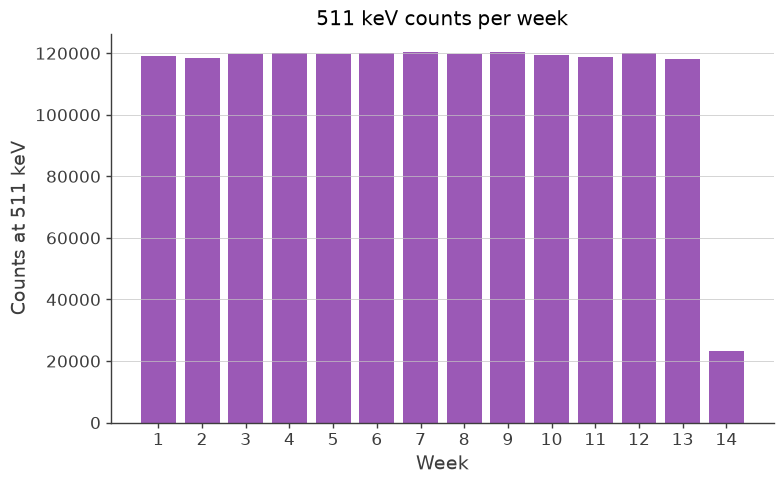

In [13]:
# Plotting the counts per week
weeks = list(analysis511)
counts = [
    np.asarray(analysis511[week].binned_data.todense().contents).sum()
    for week in weeks
]

plt.figure(figsize=(8, 5))
plt.bar(weeks, counts)
plt.xlabel("Week")
plt.ylabel("Counts at 511 keV")
plt.title("511 keV counts per week")
plt.xticks(weeks)
plt.grid(axis="y")


plt.tight_layout()
plt.show()

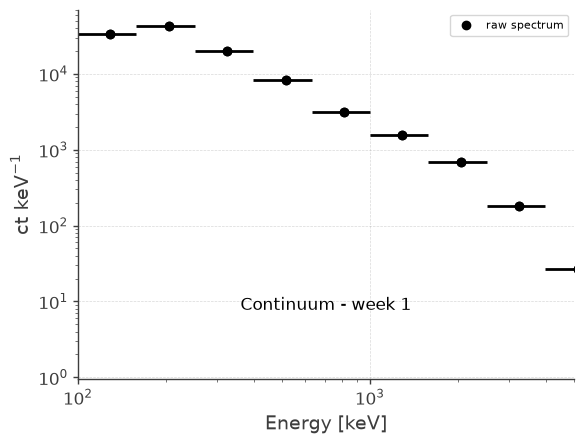

<Figure size 640x480 with 0 Axes>

In [14]:
# Plotting raw spectrum for continuum case
#week 1
fig, ax = plt.subplots()
ax.text(0.5,0.2, 'Continuum - week 1', transform=ax.transAxes, ha='center', va='center')
ax.set_frame_on(True)

analysiscon[1].get_raw_spectrum(show_plots = True)
plt.tight_layout()
plt.show()

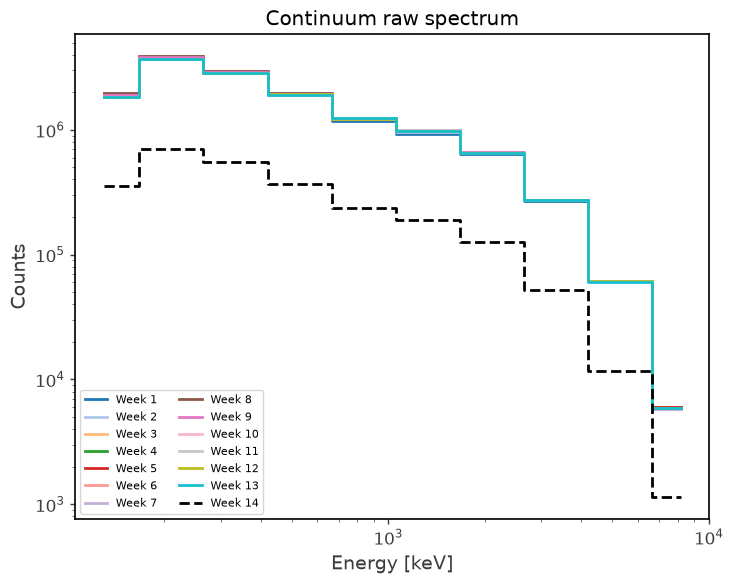

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(analysiscon)))

for color, (week, analysis) in zip(colors, analysiscon.items()):
    energy = np.asarray(analysis.energy_bin_centers)
    data = np.asarray(analysis.binned_data.todense().contents)

    energy_axis = next(
        axis for axis, size in enumerate(data.shape)
        if size == len(energy)
    )

    spectrum = data.sum(
        axis=tuple(
            axis for axis in range(data.ndim)
            if axis != energy_axis
        )
    )

    if week == 14:
        ax.step(
            energy, spectrum,
            where="mid",
            color="black",
            linestyle="--",
            label="Week 14",
        )
    else:
        ax.step(
            energy, spectrum,
            where="mid",
            color=color,
            label=f"Week {week}",
        )

ax.set(
    xlabel="Energy [keV]",
    ylabel="Counts",
    title="Continuum raw spectrum",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(ncol=2)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.2)

ax.set_frame_on(True)
plt.tight_layout()
plt.show()

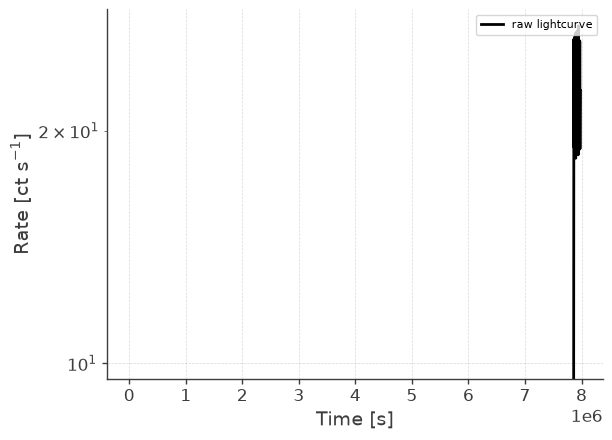

In [16]:
analysiscon[14].get_raw_lightcurve(show_plots=True)

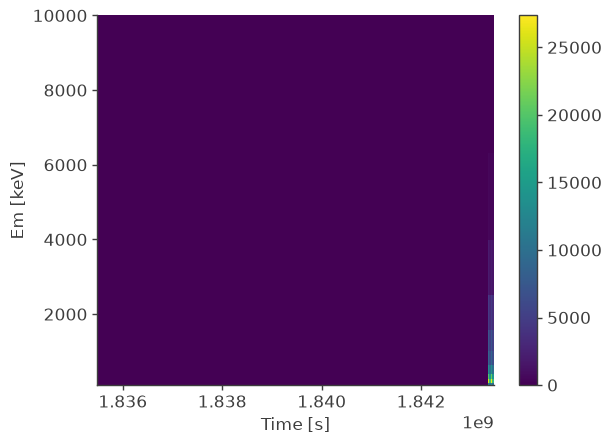

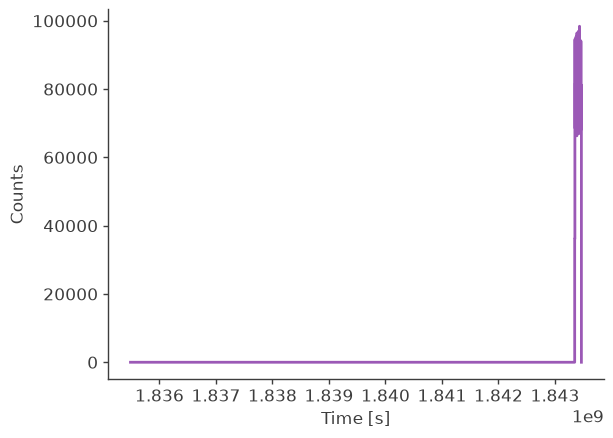

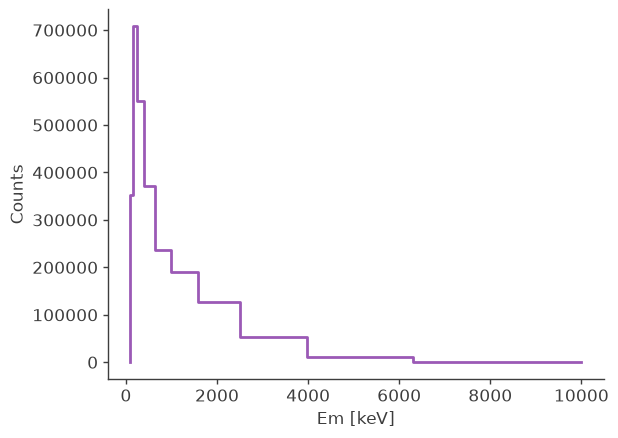

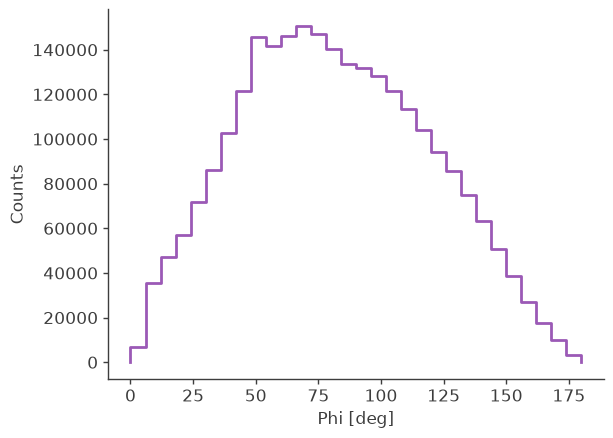

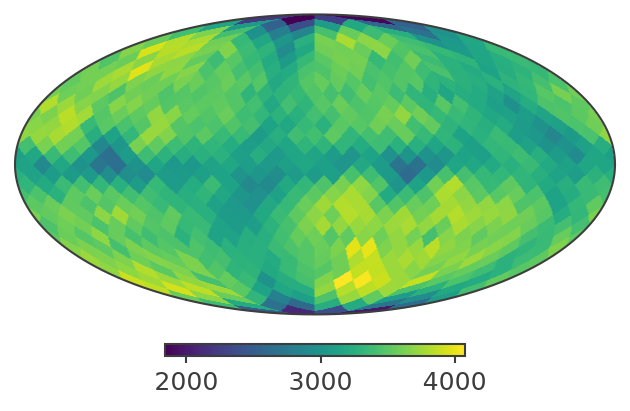

In [17]:
# Plot the binned data projected onto each axis
analysiscon[14].plot_binned_data(show_plots=True)

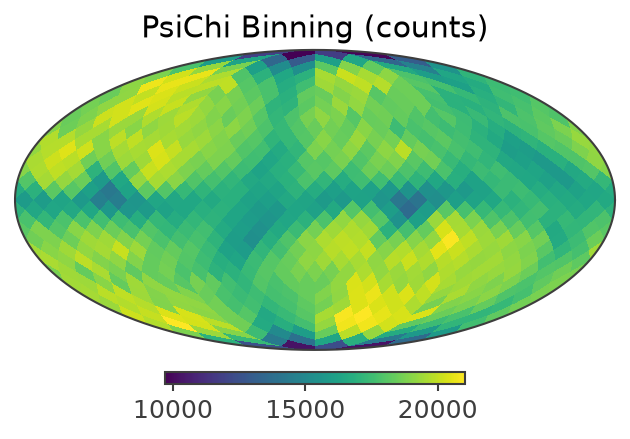

In [26]:
analysiscon[1].plot_psichi_map(show_plots=True)

***
## Detector response exploration

In [29]:
# Open and inspect the detector response
# Combine the detector response with the Crab exposure to build its observation-specific response.
# The PSR describes how photons from the Crab would be recorded by COSI.
with cp.response.FullDetectorResponse.open(data_response511_path) as response:
    print("Response 511 keV axes:", response.axes.labels)
    print('----------------------------------------------------------------')
    print('------------------------- Description --------------------------')
    print('----------------------------------------------------------------')
    print(repr(response))
    print('----------------------------------------------------------------')
    print('')
    print(f"NSIDE = {response.nside}")
    print(f"SCHEME = {response.scheme}")
    print(f"NPIX = {response.npix}")
    print(f"Pixel size = {np.sqrt(response.pixarea()).to(u.deg):.2f}")
    print('')
    print('----------------------------------------------------------------')

Response 511 keV axes: ['NuLambda' 'Ei' 'Em' 'Phi' 'PsiChi']
----------------------------------------------------------------
------------------------- Description --------------------------
----------------------------------------------------------------
FILENAME: '/Users/maura/Documents/COSI/data-challenge-4/workflow/data/inputs/Response511.o4.e509_513.s20881894470591.m2555.filtered.nonsparse.binnedimaging.imagingresponse.h5'
AXES:
  NuLambda:
    DESCRIPTION: 'Location of the simulated source in the spacecraft coordinates'
    TYPE: 'healpix'
    NPIX: 3072
    NSIDE: 16
    SCHEME: 'RING'
  Ei:
    DESCRIPTION: 'Initial simulated energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 1
    EDGES: [509.0 keV, 513.0 keV]
  Em:
    DESCRIPTION: 'Measured energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 1
    EDGES: [509.0 keV, 513.0 keV]
  Phi:
    DESCRIPTION: 'Compton angle'
    TYPE: 'linear'
    UNIT: 'deg'
    NBINS: 60
    EDGES: [0.0 deg, 3.0 deg, 6.0 deg, 9.0 deg, 12.0 deg, 15.0

In [31]:
# Open and inspect the detector response
# Combine the detector response with the Crab exposure to build its observation-specific response.
# The PSR describes how photons from the Crab would be recorded by COSI.
with cp.response.FullDetectorResponse.open(data_responsecon_path) as response:
    print("Response continuum axes:", response.axes.labels)
    print('----------------------------------------------------------------')
    print('------------------------- Description --------------------------')
    print('----------------------------------------------------------------')
    print(repr(response))
    print('----------------------------------------------------------------')
    print('')
    print(f"NSIDE = {response.nside}")
    print(f"SCHEME = {response.scheme}")
    print(f"NPIX = {response.npix}")
    print(f"Pixel size = {np.sqrt(response.pixarea()).to(u.deg):.2f}")
    print('')
    print('----------------------------------------------------------------')

Response continuum axes: ['NuLambda' 'Ei' 'Em' 'Phi' 'PsiChi']
----------------------------------------------------------------
------------------------- Description --------------------------
----------------------------------------------------------------
FILENAME: '/Users/maura/Documents/COSI/data-challenge-4/workflow/data/inputs/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5'
AXES:
  NuLambda:
    DESCRIPTION: 'Location of the simulated source in the spacecraft coordinates'
    TYPE: 'healpix'
    NPIX: 768
    NSIDE: 8
    SCHEME: 'RING'
  Ei:
    DESCRIPTION: 'Initial simulated energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 398.107 keV, 630.957 keV, 1000.0 keV, 1584.89 keV, 2511.89 keV, 3981.07 keV, 6309.57 keV, 10000.0 keV]
  Em:
    DESCRIPTION: 'Measured energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 3

In [55]:
# Inspect the detector response for one fixed direction in the COSI frame.
# A sky-fixed source moves in this frame as COSI rotates, so its final
# point-source response must include the spacecraft attitude history.


with cp.response.FullDetectorResponse.open(data_responsecon_path) as response:

    drm = response.get_interp_response(SkyCoord(lon = 0*u.deg, lat = 0*u.deg, frame = SpacecraftFrame()))

(<Axes: xlabel='Ei [keV]', ylabel='Em [keV]'>,
 <matplotlib.collections.QuadMesh at 0x12a4dccd0>)

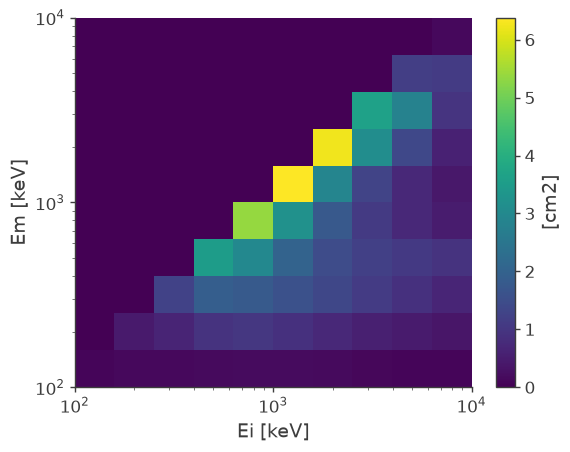

In [56]:
# effective area and the energy dispersion matrix. 
# The effective area can also be evaluated at a specific energy of interest:
# e.g.  drm.get_effective_area(energy_of_interest)
drm.get_spectral_response().plot()

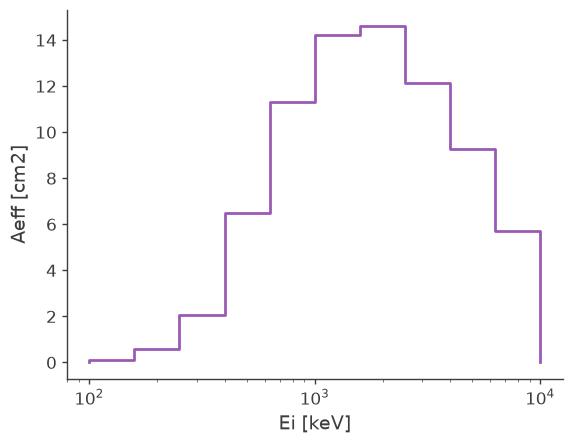

In [58]:
# The effective area can also be evaluated at a specific energy of interest:
# drm.get_effective_area(energy_of_interest)
ax,plot = drm.get_effective_area().plot();

ax.set_ylabel(f'Aeff [{drm.unit}]');

(<Axes: xlabel='Ei [keV]', ylabel='Em [keV]'>,
 <matplotlib.collections.QuadMesh at 0x12abe0cd0>)

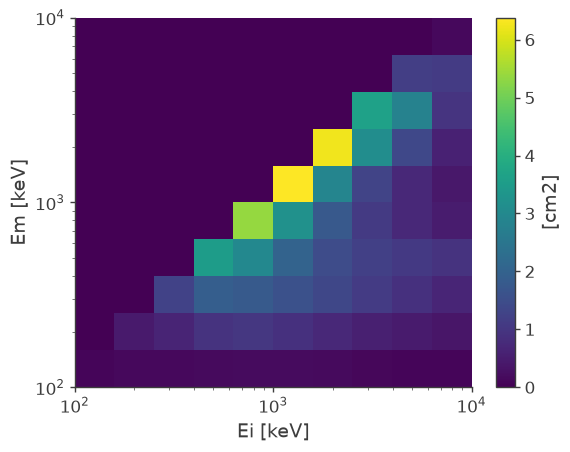

In [59]:
with cp.response.FullDetectorResponse.open(data_response511_path) as response:
    drm511 = response.get_interp_response(
        SkyCoord(
            lon=0 * u.deg,
            lat=0 * u.deg,
            frame=SpacecraftFrame(),
        )
    )

drm.get_spectral_response().plot()

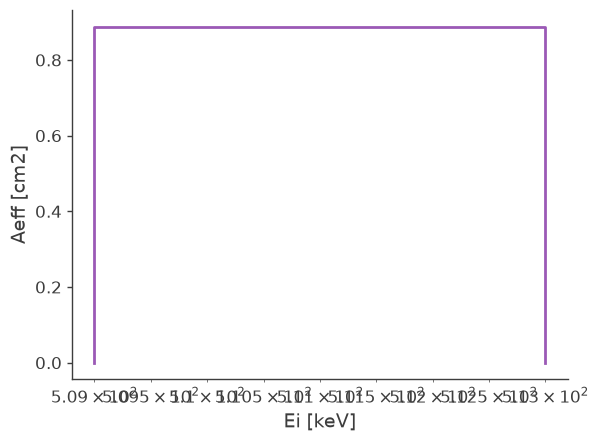

In [60]:
# The effective area can also be evaluated at a specific energy of interest:
# drm.get_effective_area(energy_of_interest)
ax,plot = drm511.get_effective_area().plot();

ax.set_ylabel(f'Aeff [{drm.unit}]');